In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../output/transactions_data_completely_clean.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10650 entries, 0 to 10649
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   home_country               10650 non-null  object 
 1   source_currency            10650 non-null  object 
 2   dest_currency              10650 non-null  object 
 3   channel                    10650 non-null  object 
 4   amount_src                 10650 non-null  float64
 5   amount_usd                 10650 non-null  float64
 6   fee                        10650 non-null  float64
 7   exchange_rate_src_to_dest  10650 non-null  float64
 8   new_device                 10650 non-null  bool   
 9   ip_country                 10650 non-null  object 
 10  location_mismatch          10650 non-null  bool   
 11  ip_risk_score              10650 non-null  float64
 12  kyc_tier                   10650 non-null  object 
 13  account_age_days           10650 non-null  int

device_trust_bucket
Low<0.3     0.849791
0.3-0.5     0.113714
0.5-0.7     0.020597
0.7-0.9     0.032920
High>0.9    0.008268
Name: is_fraud, dtype: float64


C:\Users\godfr\AppData\Local\Temp\ipykernel_58392\1297766974.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_device = df.groupby('device_trust_bucket')['is_fraud'].mean()


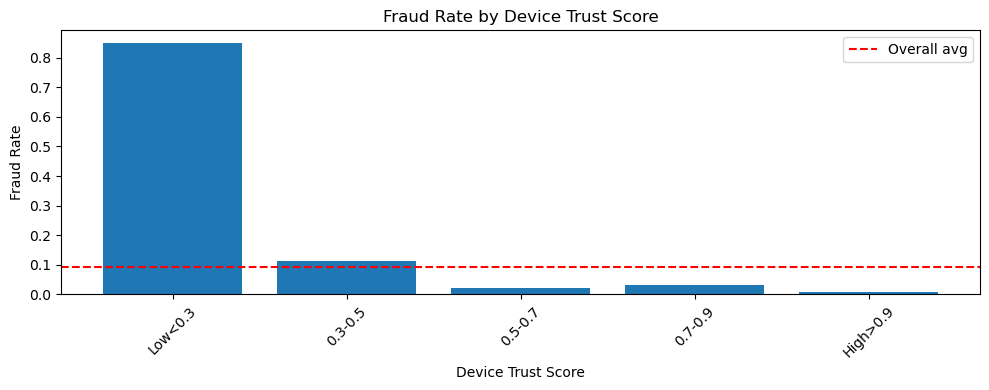

Text(0.5, 0, 'kyc_tier')

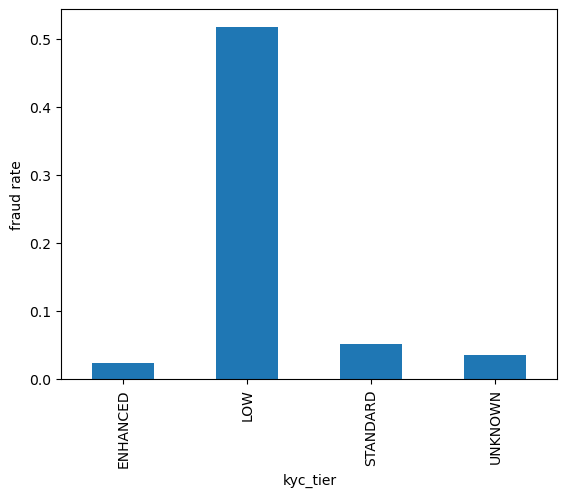

In [3]:
# Fraud rate by device trust score buckets
df['device_trust_bucket'] = pd.cut(df['device_trust_score'],
                                   bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
                                   labels=['Low<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', 'High>0.9'])

fraud_by_device = df.groupby('device_trust_bucket')['is_fraud'].mean()
print(fraud_by_device)

plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_by_device)), fraud_by_device.values)
plt.xticks(range(len(fraud_by_device)), fraud_by_device.index, rotation=45)
plt.xlabel('Device Trust Score')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Trust Score')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()


df.groupby("kyc_tier")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("kyc_tier")

### Exploring the distribution of the numerical columns

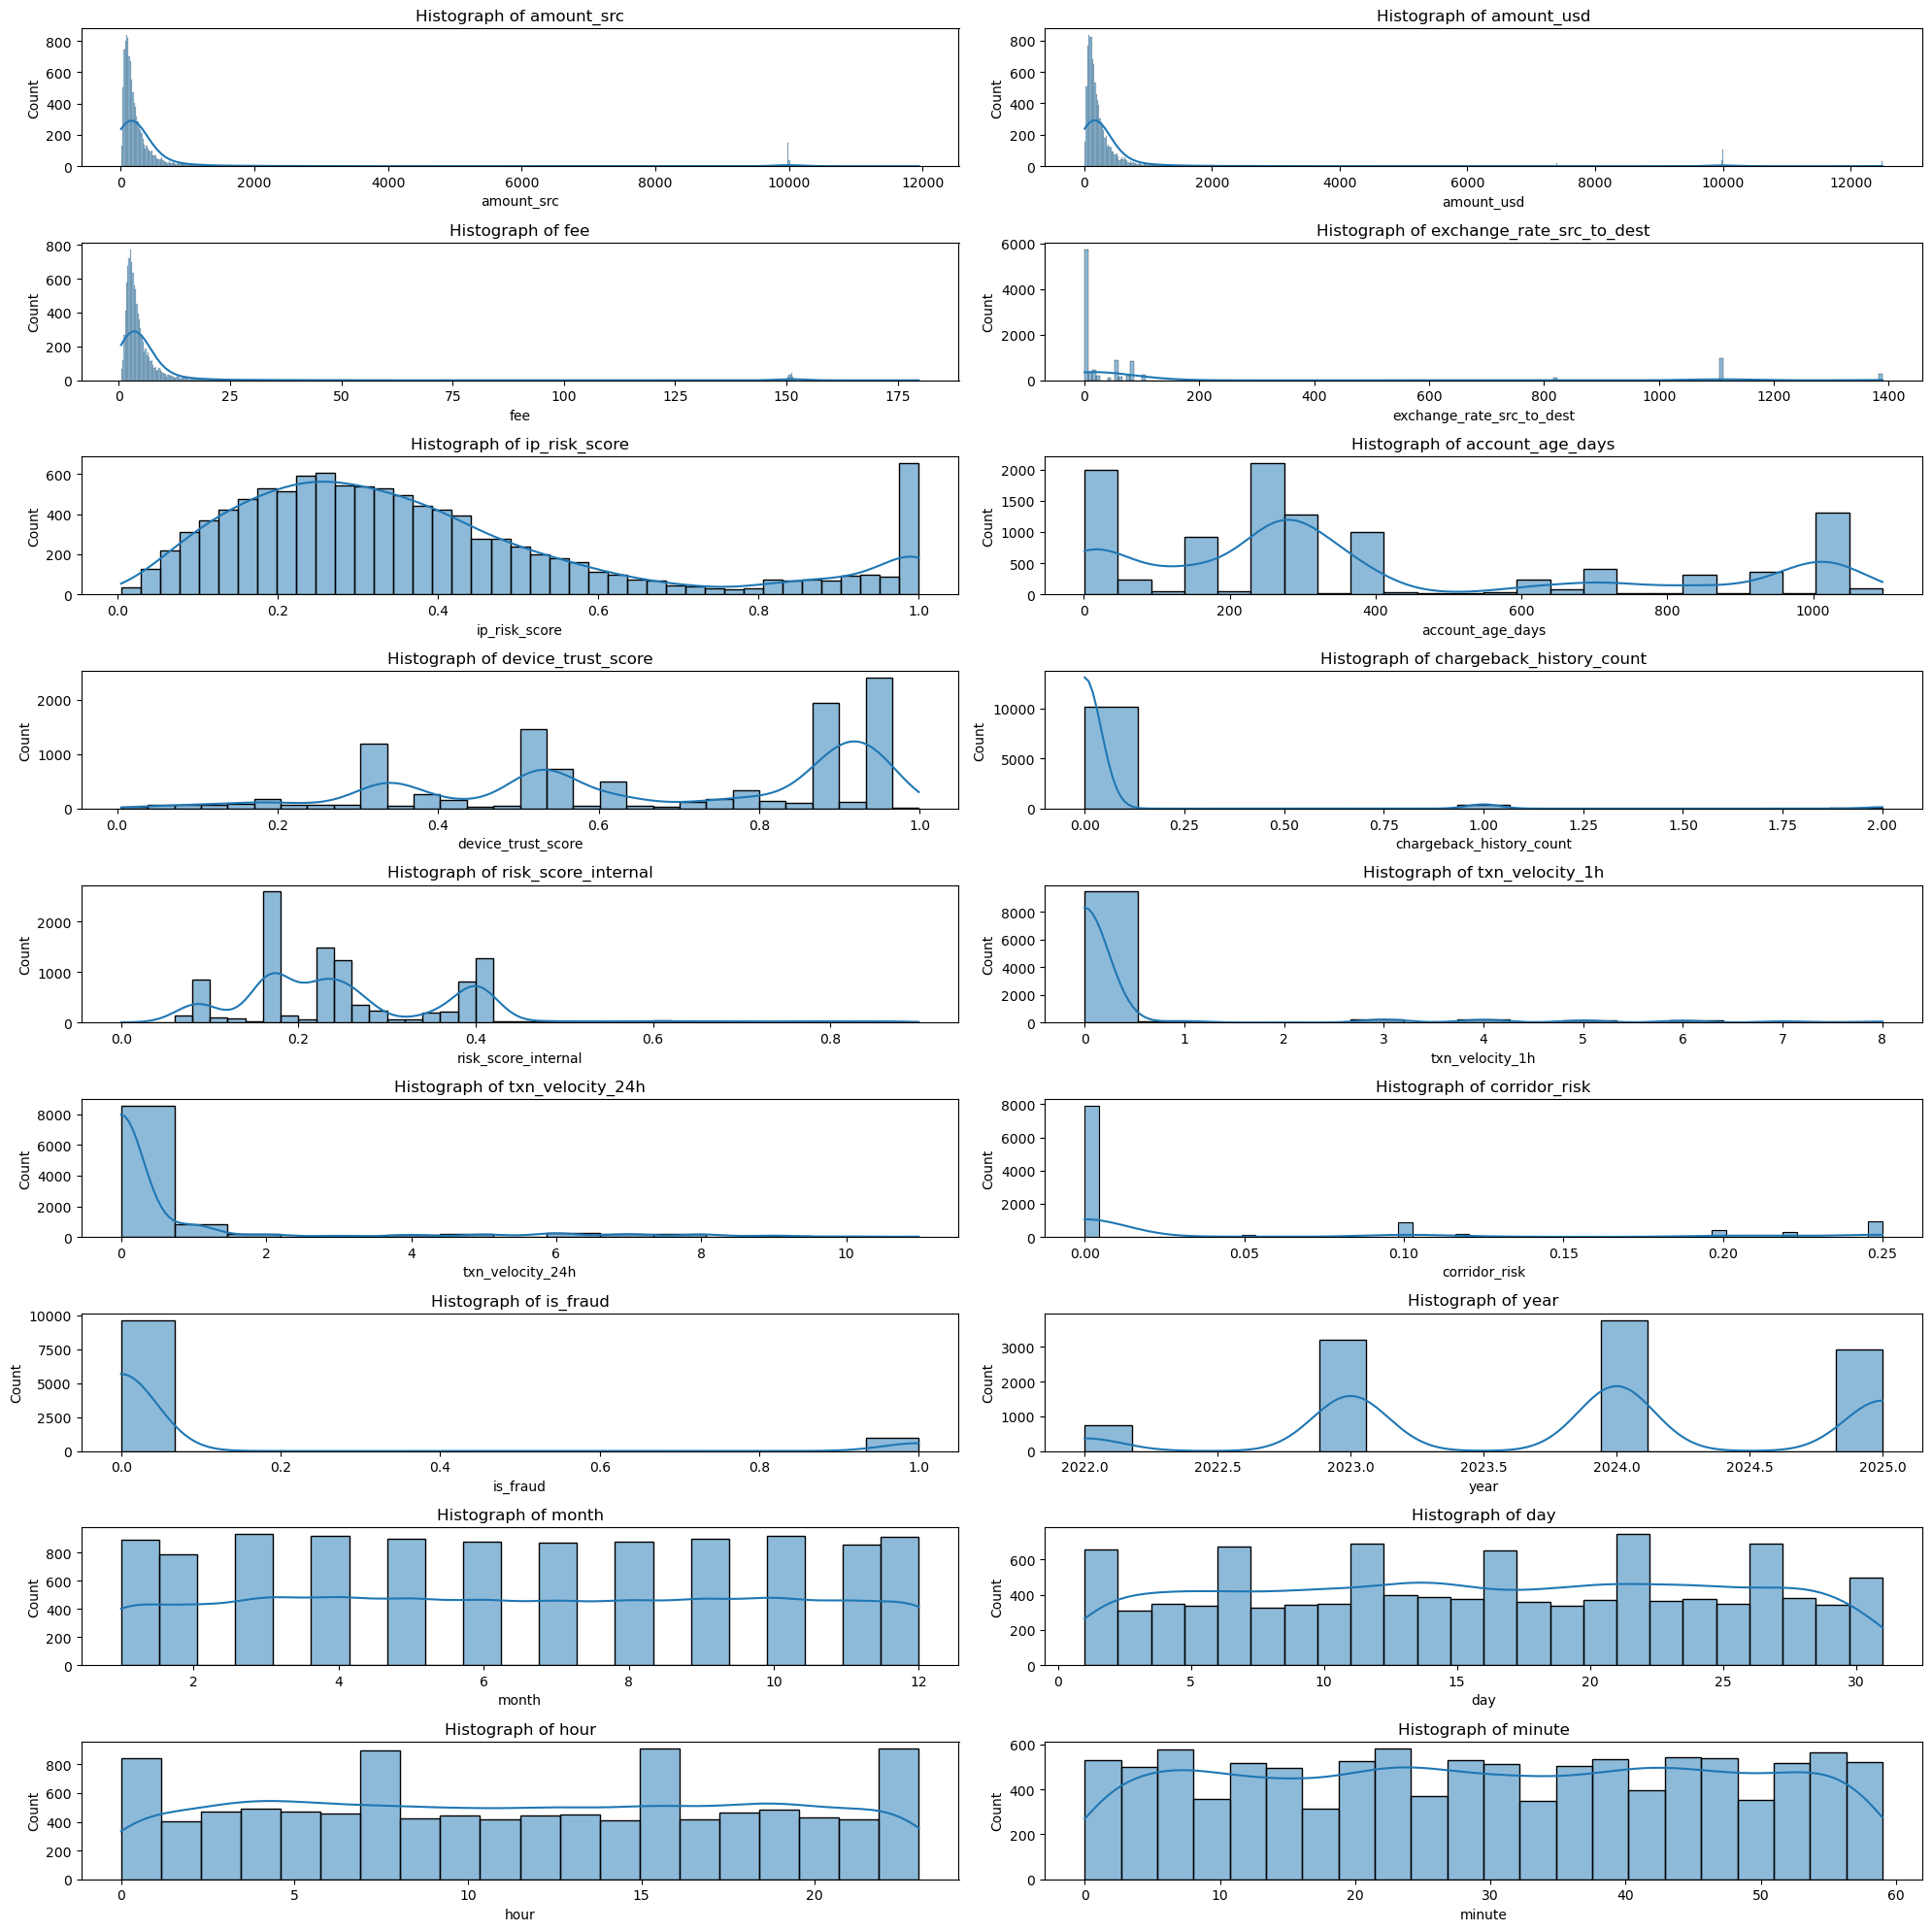

In [4]:
num_cols = df.select_dtypes(include='number')

fig, ax = plt.subplots(nrows=9, ncols=2, figsize=(20,20))
ax = ax.flatten()
for idx, column in enumerate(num_cols):
        sns.histplot(df[column], ax=ax[idx], kde=True)
        ax[idx].set_title(f"Histograph of {column}")
plt.tight_layout()
plt.show();

## Exploration of Outliers

### Checking for outliers

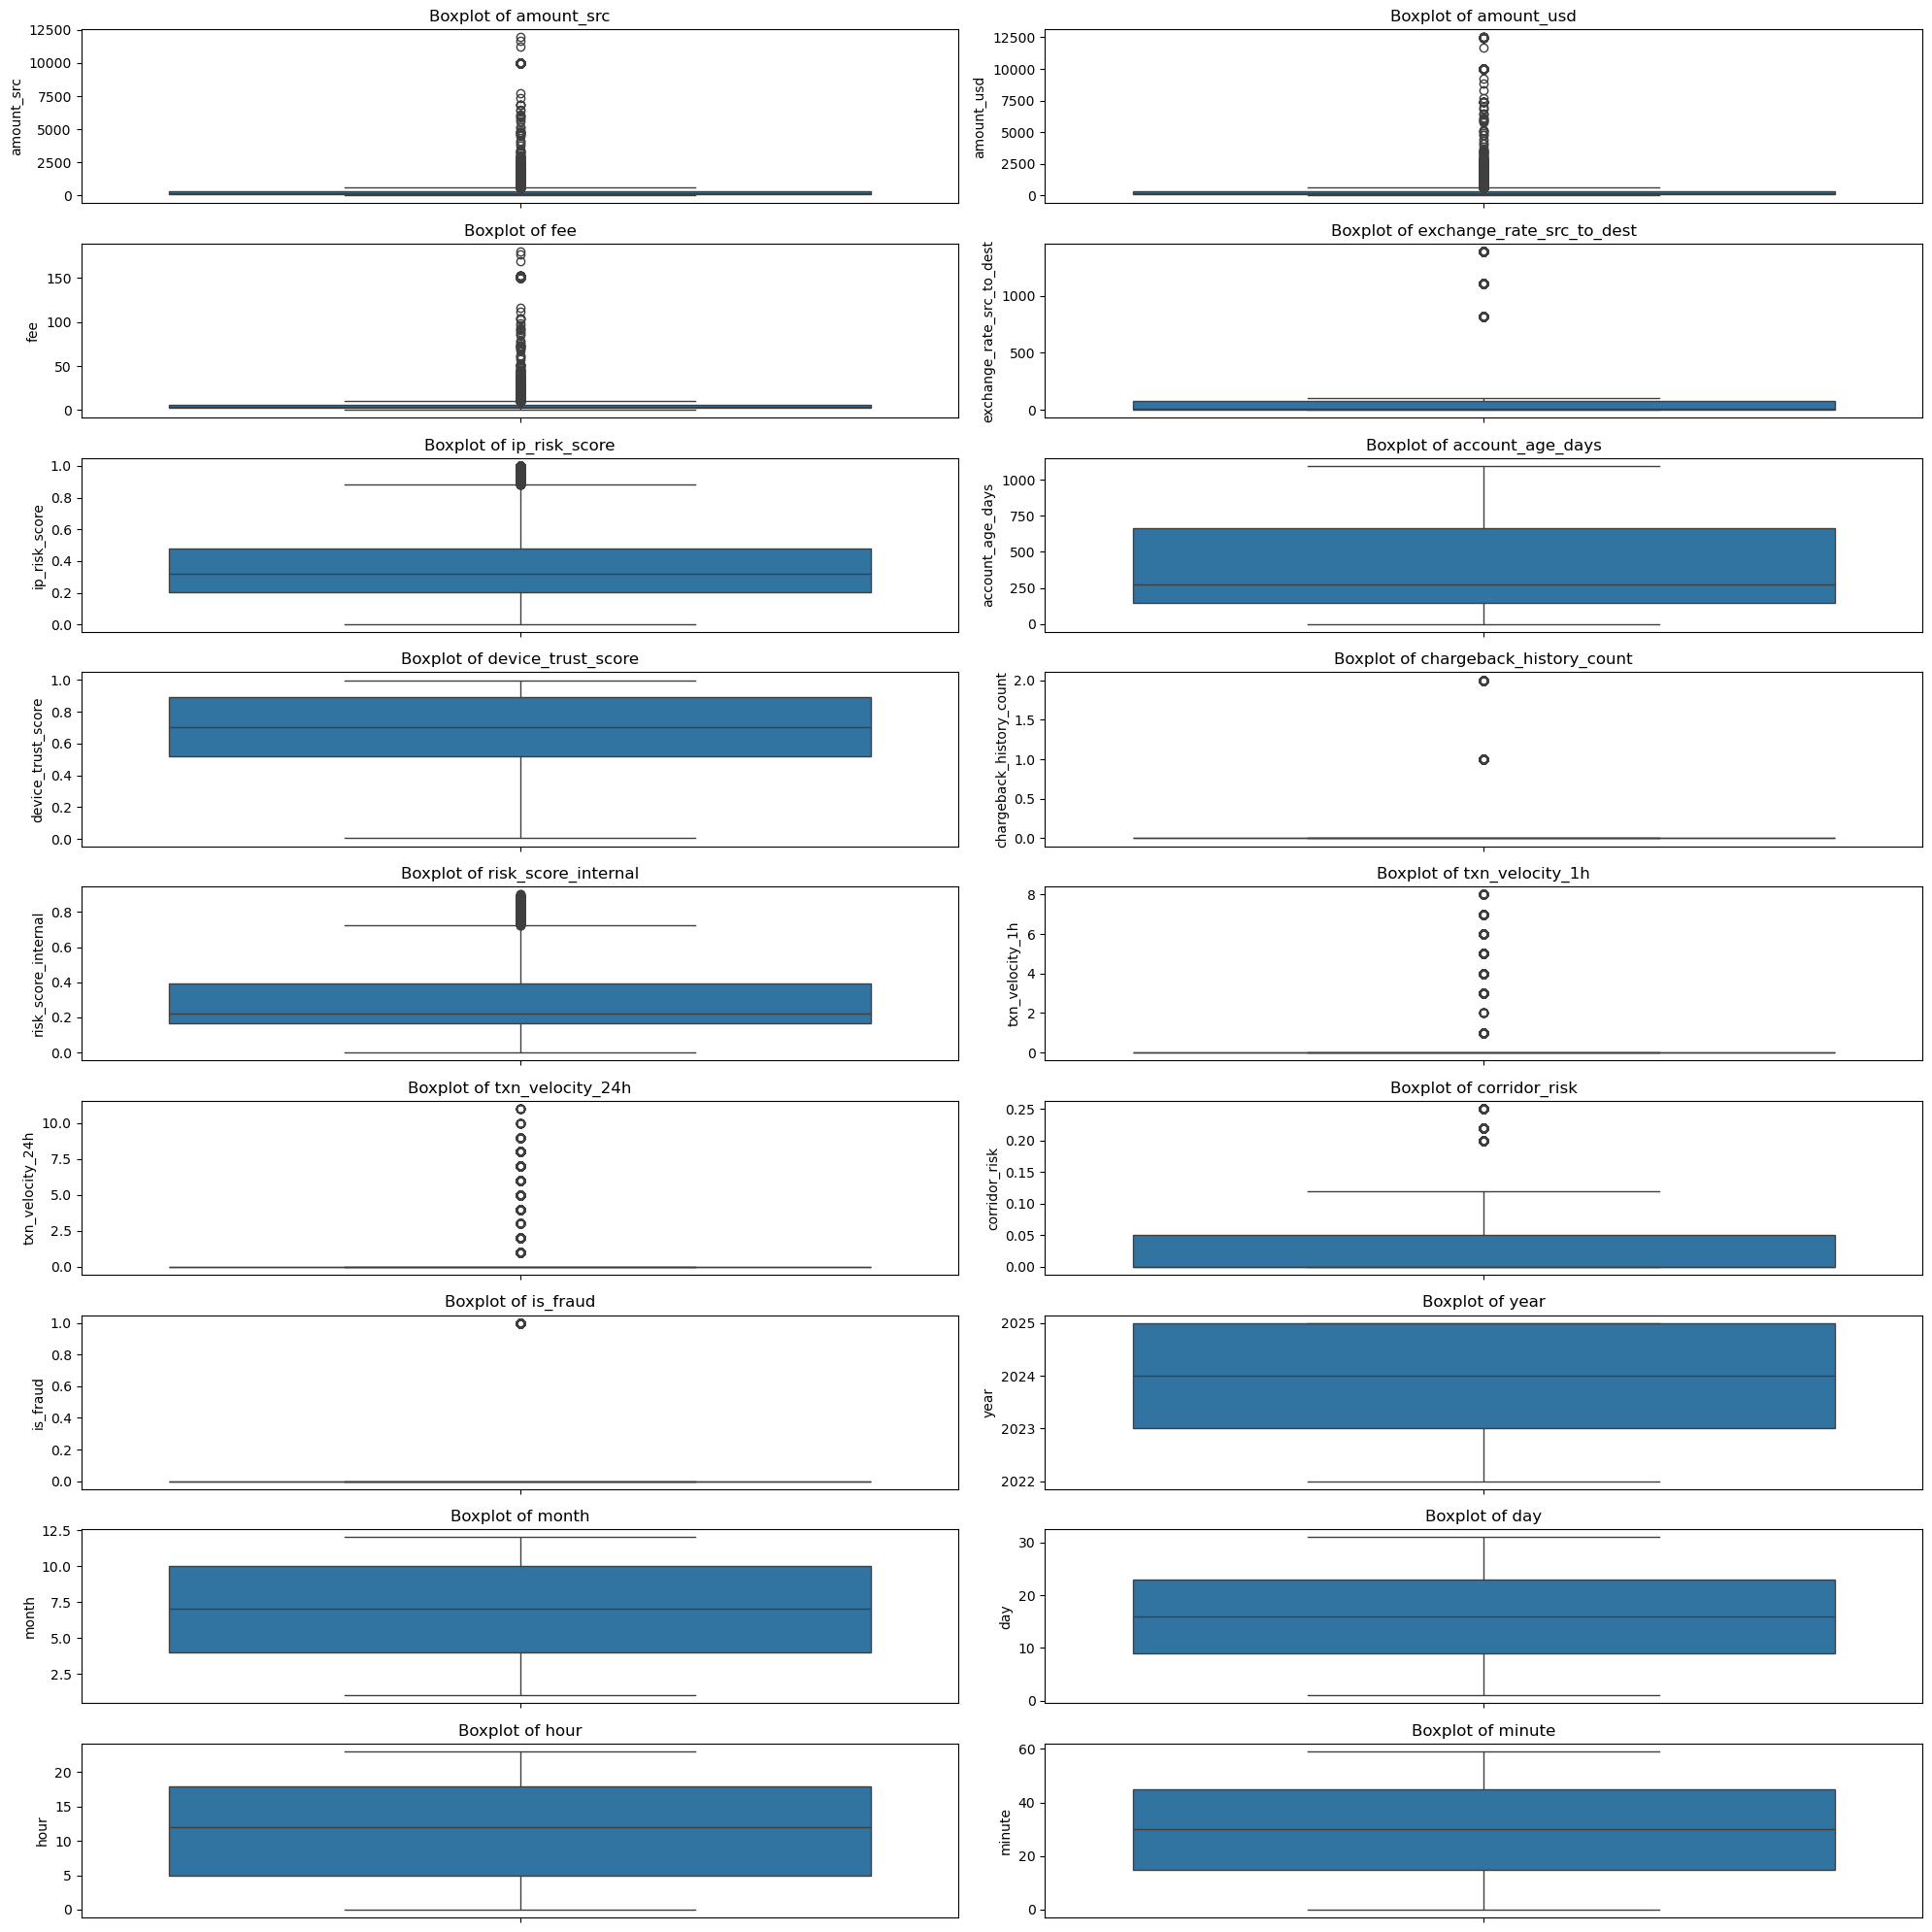

In [5]:
num_cols = df.select_dtypes(include='number')

fig, ax = plt.subplots(nrows=9, ncols=2, figsize=(20,20))
ax = ax.flatten()
for idx, column in enumerate(num_cols):
    sns.boxplot(df[column], ax=ax[idx])
    ax[idx].set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show();

**Observations**
    
    - The distributions of amount_src reveals that there are recorded transaction of values lower than 0. This suggests data quality issues and they must be investigated. 

In [6]:
df[df['amount_src'] < 0]

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,...,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day,hour,minute,device_trust_bucket


There are a total of 97 rows that indicates transactions lower than $0.

They all have a common pattern where the fee column has the value of 9999.99.

In [7]:
# confirming the above assumption in the fee column
trans_under_zero = df[df['fee'] == 9999.99]

In [8]:
with pd.option_context('display.max_columns', None):
    display(trans_under_zero)

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day,hour,minute,device_trust_bucket


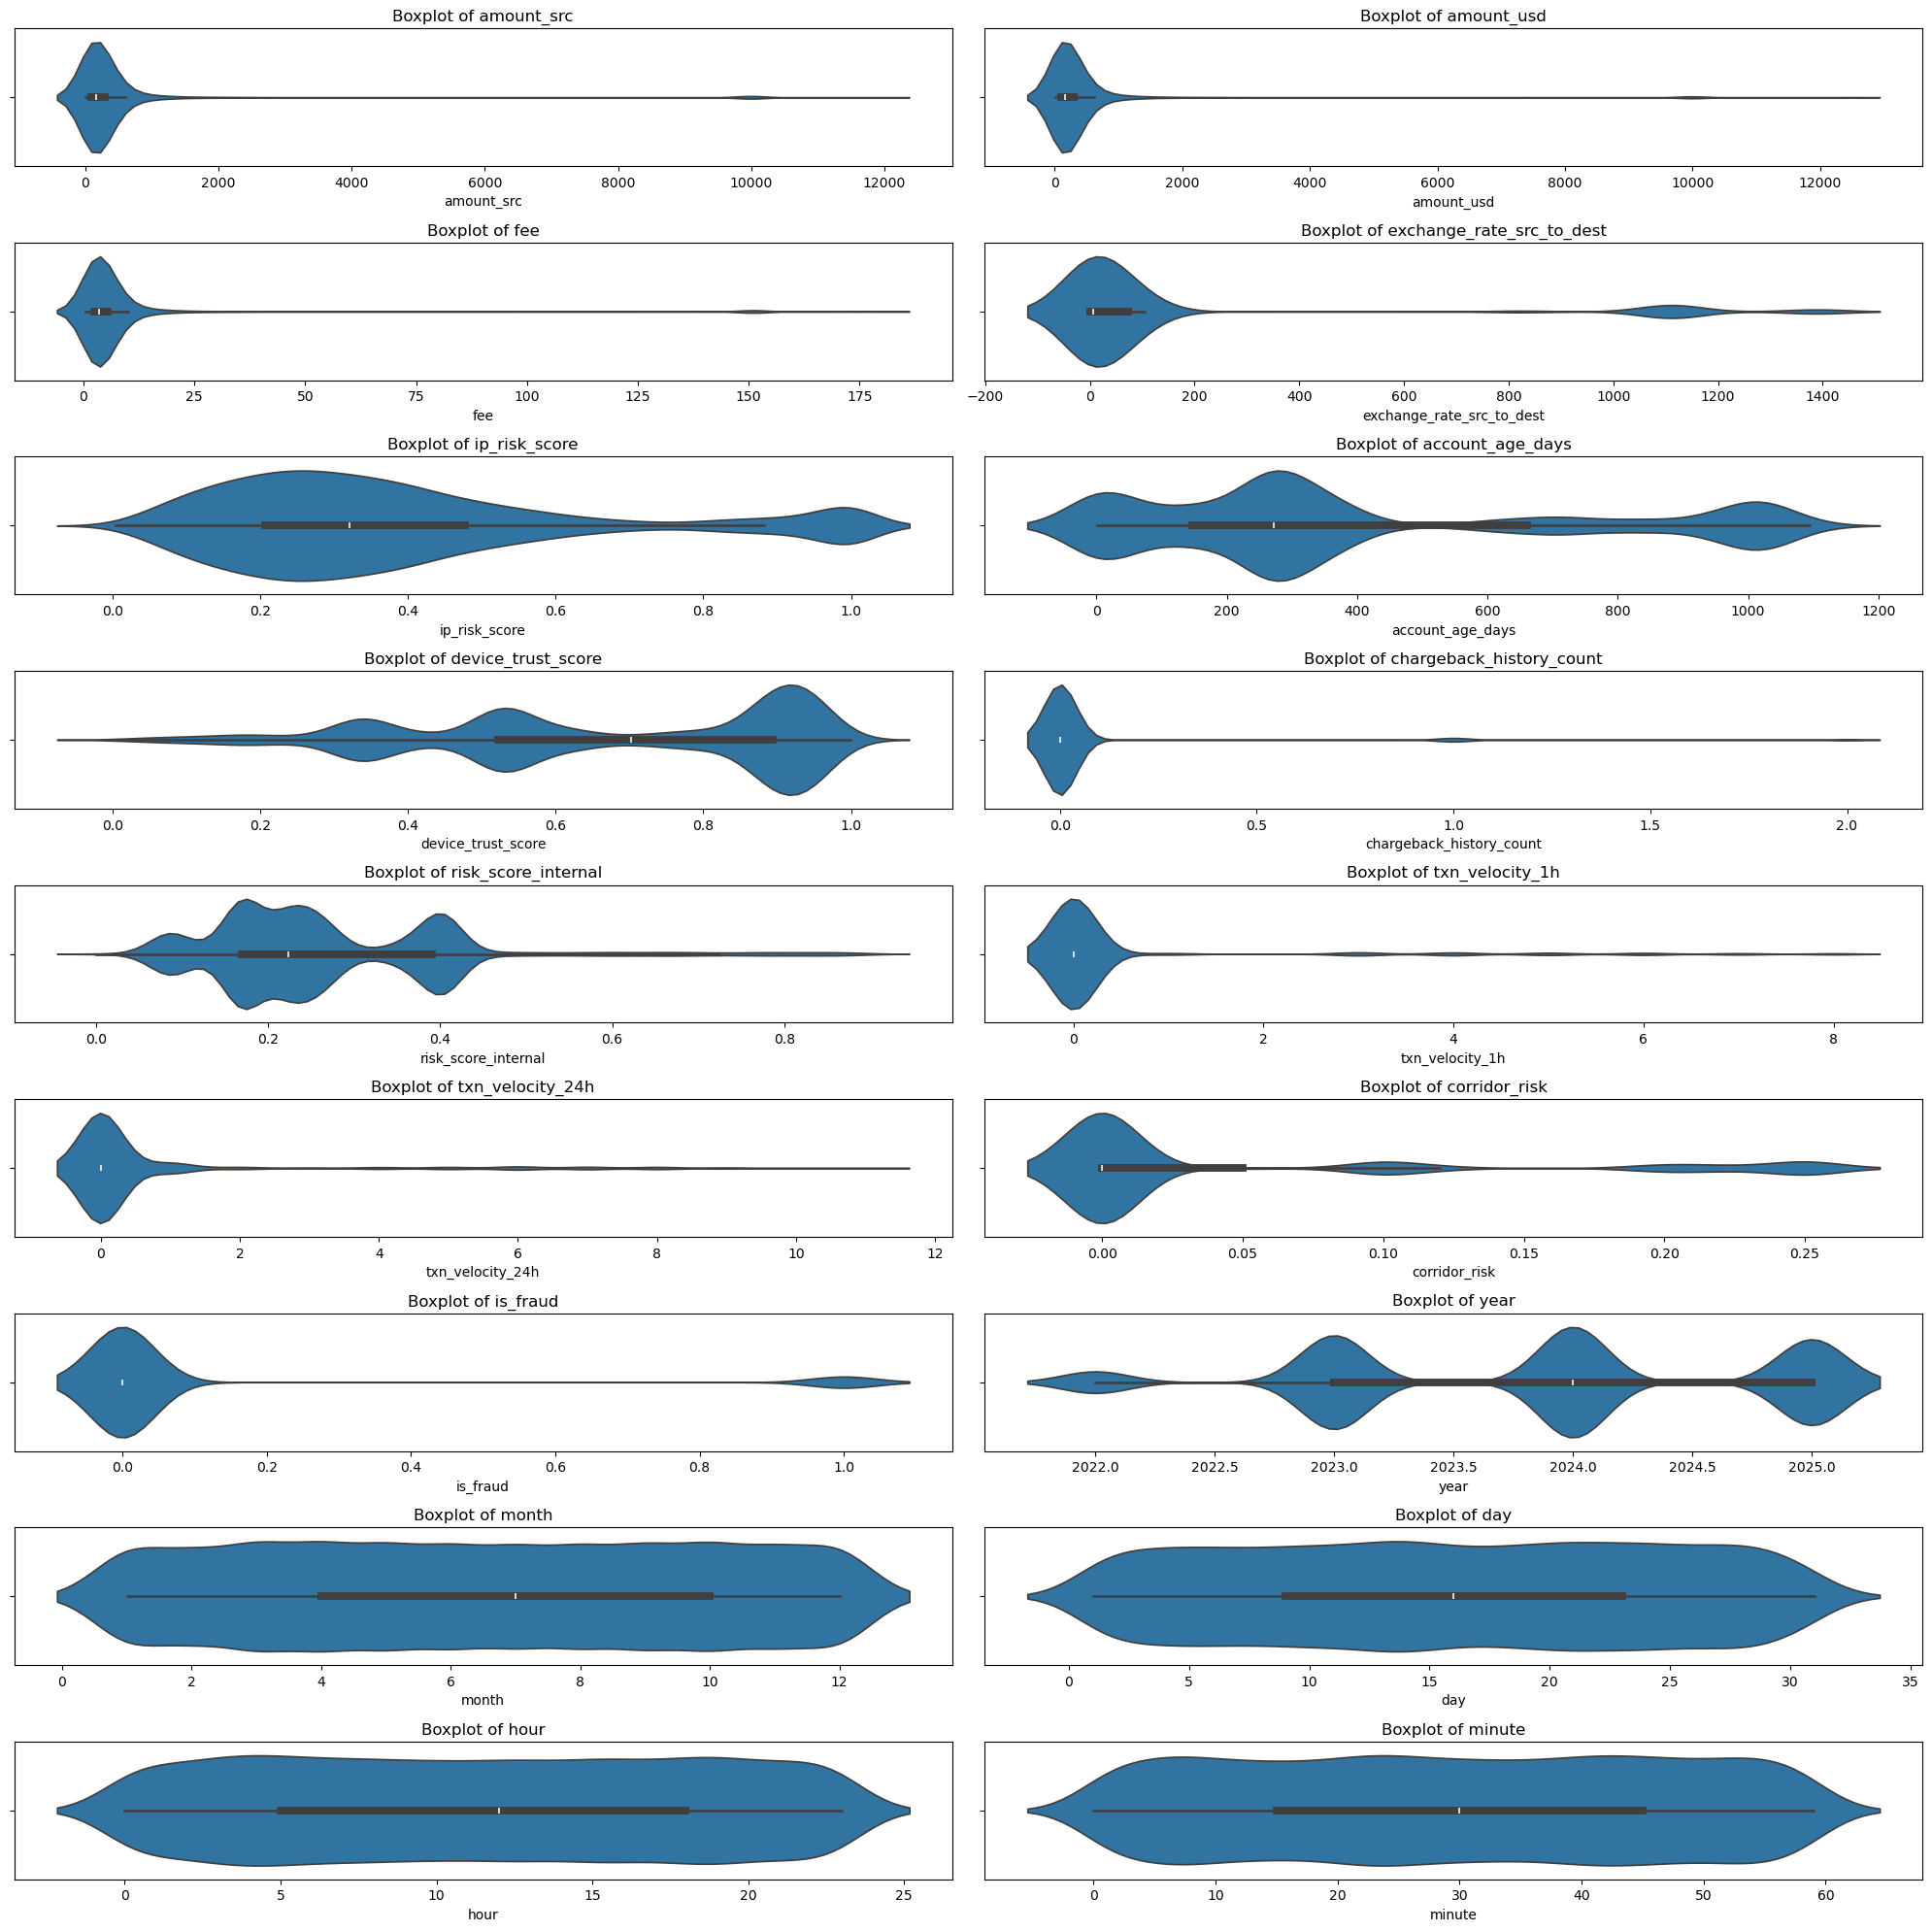

In [9]:
fig, ax = plt.subplots(nrows=9, ncols=2, figsize=(20,20))
ax = ax.flatten()

for idx, column in enumerate(num_cols):
    sns.violinplot(x=df[column], ax=ax[idx])
    ax[idx].set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show();

In [10]:
df['chargeback_history_count'].value_counts()

chargeback_history_count
0    10210
1      329
2      111
Name: count, dtype: int64

### Check for Imbalance

In [11]:
df['is_fraud'].value_counts()

is_fraud
0    9668
1     982
Name: count, dtype: int64